# SWOG — Ontology-Grounded Imaging Knowledge Graph
### End-to-end pipeline demo

**Project:** *Ontology Grounded Knowledge Graphs for Explainable Reasoning for GI Cancers* (SWOG Radiation Oncology Committee).

The full SWOG system is a **multimodal** knowledge graph:

- **Text KG** — clinical: patients, tumors, treatments, metastasis, vascular involvement
- **Visual KG** — imaging phenotypes derived from CT segmentation  ← **this notebook builds this half**
- **Phenotype Bridge** — joins the two on the *patient*

This notebook walks the **imaging (Visual) KG** pipeline end to end:

```
schema.owl (ontology, SNOMED/NCIt)          ── the vocabulary
        │
CT masks ─► phenotype records (per patient) ── the instances
        │   kg_build_graph.py
        ▼
imaging_kg.ttl  +  unified_mmkg.json         ── the persisted KG
        │   kg_query.py
        ▼
patient-level queries                        ── explainable reasoning
```

Datasets: **Pancreas (MSD), LiTS, FLARE** — 512 per-patient studies.

## 0 · Setup

In [1]:
import sys, json, subprocess
from collections import Counter
ROOT = "/home/ud3d4/Desktop/SWOG"
sys.path.insert(0, f"{ROOT}/src/scripts")
import pandas as pd
pd.set_option("display.max_colwidth", 70)
print("environment ready")

environment ready


## 1 · Obtain — the ontology (schema)

The KG is **grounded**: every organ / lesion / phenotype is a class in an OWL ontology, cross-referenced
to clinical terminologies (**SNOMED CT**, **NCIt**). This is what makes the graph *explainable* and
interoperable with the clinical Text KG.

In [2]:
from rdflib import Graph, RDF, OWL
schema = Graph(); schema.parse(f"{ROOT}/kg/schema.owl")
classes = sorted(str(s).split('/')[-1] for s in schema.subjects(RDF.type, OWL.Class))
rels    = sorted(str(s).split('/')[-1] for s in schema.subjects(RDF.type, OWL.ObjectProperty))
print(f"Ontology: {len(classes)} classes, {len(rels)} relations\n")
print("Entity classes :", ", ".join(c for c in classes if c[0].isupper())[:200])
print("Relations      :", ", ".join(rels))

Ontology: 22 classes, 9 relations

Entity classes : AnatomicSite, Anatomy, CrossOrganExtension, ImagingCase, Lesion, LesionMultiplicity, Liver, LiverTumor, Observation, OntologyConcept, Organ, OrganContainment, Pancreas, PancreaticBody, PancreaticHead,
Relations      : depicts_organ, has_lesion, has_observation, has_series, has_study, located_in, mapped_to_concept, overlaps_organ, part_of


In [3]:
# ontology grounding: imaging concept -> SNOMED CT / NCIt code
maps = json.load(open(f"{ROOT}/kg/ontology_mappings.json"))["mappings"]
rows = [{"concept": k, **{s: d.get("code") for s, d in v.items()}} for k, v in maps.items()]
pd.DataFrame(rows).fillna("—")

,concept,SNOMED CT,NCIt
0,Organ::Pancreas,15776009,C12393
1,Organ::Liver,10200004,C12392
2,AnatomicSite::Head of pancreas,362201006,—
3,AnatomicSite::Body of pancreas,40133006,—
4,AnatomicSite::Tail of pancreas,73239005,—
5,Lesion::Pancreatic tumor,372003004,C3305
6,Lesion::Liver tumor,93870000,C3099
7,Observation::Tumor diameter,263605001,—
8,Observation::Tumor volume,258261001,—
9,Observation::Tumor burden,—,C28384


## 2 · Obtain — the phenotype instances

Every CT study is run through our SAM3 segmentation models; from the masks we extract a **per-patient
phenotype record**: which organs are observed, tumor presence, **burden** (low/med/high), **multiplicity**
(solitary/multifocal), **containment**, anatomic **sub-site**, and cross-organ extension. These are the
graph's instances.

In [4]:
corpus = json.load(open(f"{ROOT}/kg/data/corpus_perpatient.json"))["records"]
print("per-patient studies:", len(corpus), "|", dict(Counter(r["dataset"] for r in corpus)))
ex = next(r for r in corpus if r["dataset"] == "pancreas" and r["organs"]["pancreas"]["has_tumor"])
print("\nexample patient:", ex["case_id"], "— observed organs:", ex["observed_organs"])
pd.json_normalize(ex["organs"]["pancreas"]).T.rename(columns={0: ex["case_id"] + " · pancreas"})

per-patient studies: 512 | {'pancreas': 281, 'lits': 131, 'flare': 100}

example patient: pancreas_001 — observed organs: ['pancreas']


,pancreas_001 · pancreas
present,True
organ_volume_cm3,39.81
has_tumor,True
tumor_volume_cm3,24.26
tumor_voxels,24260
burden_cat,high
multiplicity,solitary
containment,boundary
anatomic_location,head
size_cat,unknown


## 3 · Obtain — build the persisted KG

`kg_build_graph.py` materializes the graph: `ImagingCase → Organ → Lesion → Observation`, adds a
**Patient** node per study (the bridge key), grounds concepts to SNOMED/NCIt, and writes two artifacts:

- **`imaging_kg.ttl`** — canonical RDF/Turtle (loads in any triplestore)
- **`unified_mmkg.json`** — nodes+edges (fast to load / app-ingestible)

In [5]:
out = subprocess.run([sys.executable, f"{ROOT}/src/scripts/kg_build_graph.py"],
                     capture_output=True, text=True, cwd=ROOT)
print(out.stdout.strip() or out.stderr[-500:])

KG built from 512 ImagingCases (512 patient-level) [corpus_perpatient.json] -> /home/ud3d4/Desktop/SWOG/kg/graph/imaging_kg.ttl + unified_mmkg.json
Triples: 17266
Nodes (3508): Organ=907, ImagingCase=512, Patient=512, Lesion=388, TumorBurden=388, LesionMultiplicity=388, OrganContainment=388, OntologyConcept=19, Dataset=3, AnatomicSite=3
Edges (6116): mapped_to_concept=1964, has_observation=1164, depicts_organ=907, from_dataset=512, of_patient=512, has_lesion=388, located_in=388, at_site=281
Grounded concepts: 14


## 4 · Inspect the graph

In [6]:
G = json.load(open(f"{ROOT}/kg/graph/unified_mmkg.json"))
nodes = {n["id"]: n for n in G["nodes"]}
print("Nodes by type :", dict(Counter(n["type"] for n in G["nodes"])))
print("Edges by rel  :", dict(Counter(e["relation"] for e in G["edges"])))

Nodes by type : {'OntologyConcept': 19, 'ImagingCase': 512, 'Dataset': 3, 'Patient': 512, 'Organ': 907, 'Lesion': 388, 'TumorBurden': 388, 'LesionMultiplicity': 388, 'OrganContainment': 388, 'AnatomicSite': 3}
Edges by rel  : {'from_dataset': 512, 'of_patient': 512, 'depicts_organ': 907, 'mapped_to_concept': 1964, 'has_lesion': 388, 'located_in': 388, 'has_observation': 1164, 'at_site': 281}


### One patient's subgraph
The graph below is the neighborhood of a single pancreatic-cancer patient — case → patient, the depicted
organ, its lesion, the phenotype observations, the anatomic sub-site, and the grounded ontology concepts.
This is the unit the whole KG is built from.

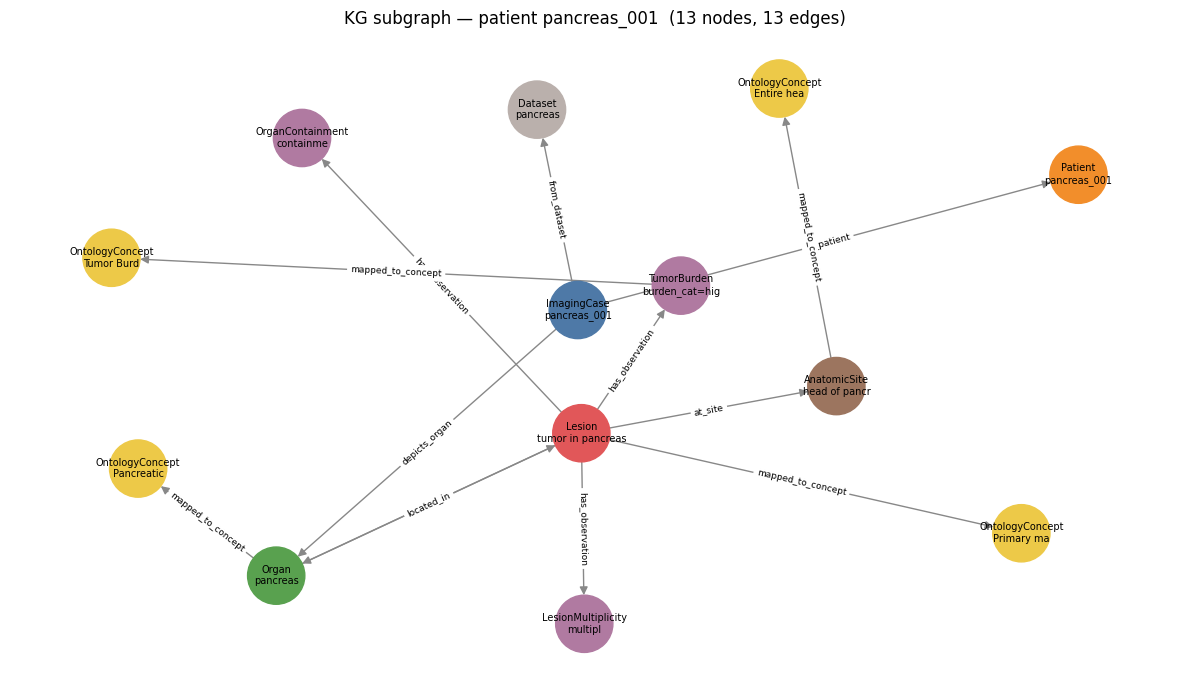

In [7]:
import networkx as nx, matplotlib.pyplot as plt
adj = {}
for e in G["edges"]:
    adj.setdefault(e["source"], []).append((e["relation"], e["target"]))
seed = "case_pancreas_001"; keep = {seed}; frontier = [seed]
for _ in range(4):
    nxt = []
    for n in frontier:
        for _, t in adj.get(n, []):
            if t not in keep: keep.add(t); nxt.append(t)
    frontier = nxt
NG = nx.DiGraph()
for e in G["edges"]:
    if e["source"] in keep and e["target"] in keep:
        NG.add_edge(e["source"], e["target"], label=e["relation"])
COLOR = {"ImagingCase":"#4e79a7","Patient":"#f28e2b","Organ":"#59a14f","Lesion":"#e15759",
         "TumorBurden":"#b07aa1","LesionMultiplicity":"#b07aa1","OrganContainment":"#b07aa1",
         "AnatomicSite":"#9c755f","OntologyConcept":"#edc948"}
def short(nid):
    n = nodes.get(nid, {}); lab = n.get("label", nid.split("_")[-1])
    return f"{n.get('type','?')}\n{lab}"[:26]
pos = nx.spring_layout(NG, seed=3, k=1.1)
plt.figure(figsize=(12, 7))
nx.draw_networkx_nodes(NG, pos, node_size=1700,
    node_color=[COLOR.get(nodes.get(n,{}).get("type"), "#bab0ac") for n in NG])
nx.draw_networkx_edges(NG, pos, edge_color="#888", arrows=True, arrowsize=12, node_size=1700)
nx.draw_networkx_labels(NG, pos, {n: short(n) for n in NG}, font_size=7)
nx.draw_networkx_edge_labels(NG, pos, {(u,v): d["label"] for u,v,d in NG.edges(data=True)}, font_size=6.5)
plt.title(f"KG subgraph — patient pancreas_001  ({NG.number_of_nodes()} nodes, {NG.number_of_edges()} edges)")
plt.axis("off"); plt.tight_layout(); plt.show()

## 5 · Validate

Two checks: (a) **ontology grounding** — imaging concepts resolve to SNOMED/NCIt; (b) **phenotype
extraction quality** — extracted (from prediction) vs ground-truth phenotypes.

In [8]:
grounded = Counter(e["relation"] for e in G["edges"])["mapped_to_concept"]
concepts = [n for n in G["nodes"] if n["type"] == "OntologyConcept"]
print(f"OntologyConcept nodes: {len(concepts)} | mapped_to_concept edges: {grounded}")
try:
    t2 = json.load(open(f"{ROOT}/kg/data/table2_phenotype_extraction.json"))
    print("\nphenotype extraction quality (extracted vs GT):")
    print(json.dumps(t2, indent=0)[:400])
except Exception as e:
    print("(table2 phenotype-quality JSON:", e, ")")

OntologyConcept nodes: 19 | mapped_to_concept edges: 1964

phenotype extraction quality (extracted vs GT):
{
"table": "Table 2 - Imaging phenotype extraction quality",
"caption_source": "JBI_VKG_2026.pdf Table 2",
"method": "Phenotypes extracted identically from SAM3 prediction and from ground-truth masks; agreement measured (Accuracy + macro-F1, 1000x bootstrap 95% CI). Pooled over Pancreas (281) + LiTS (131) cases. Predictions are box-prompted (semi-oracle).",
"rows": [
{
"phenotype": "Organ containm


## 6 · Query — patient-level reasoning

`kg_query.py` runs **complex, multi-hop, patient-level** queries over the graph — the kind of
explainable cohort questions the KG exists to answer.

In [9]:
from kg_query import KG, QUERIES
kg = KG()
print(f"KG loaded: {len(kg.patients)} patients, {len(kg.nodes)} nodes")
res = QUERIES(kg)
pd.DataFrame([{"query": k, "count": (len(v) if isinstance(v, list) else v)} for k, v in res.items()])

KG loaded: 512 patients, 3508 nodes


,query,count
0,patients_total,512
1,patients_flare,100
2,patients_observing_pancreas,381
3,patients_multi_organ_ge2,100
4,patients_with_pancreatic_tumor,281
5,patients_high_burden_any_tumor,130
6,high_burden_pancreatic_tumor,94
7,cross_organ_tumor,0
8,multifocal_liver_tumor,72
9,contained_pancreatic_head_tumor,71


> **Reading the results (data honesty).** Tumor queries resolve for **Pancreas** and **LiTS** patients
> (per-patient tumor annotations). `cross_organ_tumor = 0` is **expected, not a bug**: the per-patient
> **FLARE (FLARE22) set is organs-only — no tumor label** — so its 100 patients contribute organ/observability
> facts but no lesions. (Cross-organ tumor is a property of the *slice-level* FLARE23 reconstruction, which is
> a separate, non-patient-level graph.) So patient-level *tumor* reasoning currently covers the 412
> tumor-annotated patients; FLARE contributes the multi-organ coverage.

## 7 · The SWOG use-case — Q1: *Whipple surgery, lymph-node recurrence*

The flagship SWOG query is **multimodal**: *Whipple surgery* and *lymph-node recurrence* live in the
**Text KG**; the **imaging** half is *"patients with a pancreatic-head tumor"* (Whipple = pancreatic-head
resection). Our KG answers that half and exposes each match by **`patient_id`** — the join key the
Phenotype Bridge uses to combine with the clinical KG.

In [10]:
whipple_cohort = kg.patients_where(
    lambda c: any(kg.at_site(l, "head") for _, l in kg.organ_lesions(c, "pancreas")))
print(f"Whipple-relevant imaging cohort (pancreatic-head tumor): {len(whipple_cohort)} patients\n")
rows = []
for p in whipple_cohort[:8]:
    cid = kg.prop(p, "patient_id"); o, l = next(kg.organ_lesions(f"case_{cid}", "pancreas"))
    rows.append({"patient_id": cid, "burden": kg.obs_value(l, "TumorBurden"),
                 "containment": kg.obs_value(l, "OrganContainment"),
                 "tumor_cm3": kg.prop(l, "volume_cm3"),
                 "→ bridge to Text KG": "Whipple? recurrence?"})
pd.DataFrame(rows)

Whipple-relevant imaging cohort (pancreatic-head tumor): 190 patients



,patient_id,burden,containment,tumor_cm3,→ bridge to Text KG
0,pancreas_001,high,boundary,24.26,Whipple? recurrence?
1,pancreas_004,high,boundary,28.31,Whipple? recurrence?
2,pancreas_005,medium,boundary,3.58,Whipple? recurrence?
3,pancreas_006,high,boundary,9.27,Whipple? recurrence?
4,pancreas_010,high,boundary,52.89,Whipple? recurrence?
5,pancreas_012,high,boundary,8.26,Whipple? recurrence?
6,pancreas_015,high,contained,6.22,Whipple? recurrence?
7,pancreas_016,high,contained,6.24,Whipple? recurrence?


## Summary

| Stage | Artifact | Status |
|---|---|---|
| **Obtain** | `schema.owl` + phenotype instances → `imaging_kg.ttl` / `unified_mmkg.json` | ✅ persisted KG |
| **Validate** | ontology grounding (SNOMED/NCIt), phenotype quality | ✅ |
| **Evaluate** | observability-aware retrieval / integration (`kg_*` scripts) | ✅ |
| **Query** | patient-level complex queries (`kg_query.py`) | ✅ |

**This half is done.** The imaging KG is patient-keyed and ready to bridge into the clinical **Text KG**
(the other half of the multimodal system) to answer end-to-end queries like Q1.

**Next:** integrate the Text KG on `patient_id` so *Whipple + recurrence + imaging phenotype* runs as one query.